# Multi-fidelity Nested RNN
This notebook guidance on how to train `MF-Nest-RNN` of the `MF-VeBRNN` repo.

In [1]:

import torch
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from MFVeBRNN.dataset.load_dataset import  MultiFidelityDataset
from MFVeBRNN.method.mf_nest_rnn_trainer import MFNestRNNTrainer
from torch import nn
import warnings
warnings.filterwarnings("ignore")

## Load dataset

In [2]:
dataset = MultiFidelityDataset(lf_train_data_path = "lf_dns_sve_0d1.pickle",
                         hf_train_data_path= "hf_dns_rve_0d1.pickle",
                         id_ground_truth=True,
                         id_hf_test_data_path="hf_dns_rve_0d1_gt.pickle",
                         id_lf_ground_truth_data_path="lf_dns_sve_0d1_gt.pickle",
                         ood_ground_truth=True,
                         ood_hf_test_data_path="hf_dns_rve_0d125_gt.pickle",
                         ood_lf_ground_truth_data_path="lf_dns_sve_0d125_gt.pickle",)
dataset.get_hf_train_val_split(num_hf_train=100, num_hf_val=10, seed=0)
dataset.get_lf_train_val_split(num_lf_train=100, num_lf_val=0, seed=0)

The dataset is loaded successfully.
Number of low-fidelity training samples: 2981
Number of high-fidelity training samples: 1291
Number of in-distribution test samples: 99
Number of out-of-distribution test samples: 99


## Define a simple GRU network 
Since the history dependent constitutive law is has recurrent data structure, we need a recurrent neural network for this task. 

In [3]:
class SimpleGRU(nn.Module):
    def __init__(self,
                 input_size: int,
                 hidden_size: int,
                 num_layers: int,
                 output_size: int,
                 bias: bool = True):
        super().__init__()
        self.gru = nn.GRU(input_size=input_size,
                          hidden_size=hidden_size,
                          num_layers=num_layers,
                          bias=bias,
                          batch_first=True,
                        )
        self.h2y = nn.Linear(hidden_size, output_size)

    def forward(self, x, hx=None):
        out, _ = self.gru(x, hx)      # (B, T, hidden_size)
        y = self.h2y(out)             # (B, T, output_size)
        return y

## Training setup

In [4]:

# define the high-fidelity model
hf_network = SimpleGRU(input_size=67,
                    hidden_size=64,
                    num_layers=2,
                    output_size=3)

# load the pre-trained low-fidelity model
lf_pre_trained_model = torch.load("single_fidelity_rnn_model.pth", weights_only=False)
# lf_pre_trained_model = torch.load("sf_vebrnn_trainer.pth", weights_only=False)

mf_model = MFNestRNNTrainer(
    pre_trained_lf_model=lf_pre_trained_model,
    net=hf_network,
    nest_option="hidden",
    device=torch.device("cuda" if torch.cuda.is_available() else "cpu"),
    seed=1
)
mf_model.configure_optimizer_info(optimizer_name="Adam",
                                    lr=0.001,
                                    weight_decay=0.0)
mf_model.configure_loss_function(loss_name="MSE")

# train the high-fidelity model
_, best_epoch = mf_model.train(
    hx_train=dataset.hx_train,
    hy_train=dataset.hy_train,
    hx_val=dataset.hx_val,
    hy_val=dataset.hy_val,
    num_epochs=1000,
    batch_size=200,
    print_iter=100,
    verbose=True,
)
# save the mf model




Epoch/Total: 0/1000, Train Loss: 9.528e-01, Val Loss: 8.541e-01
Epoch/Total: 100/1000, Train Loss: 2.435e-02, Val Loss: 2.139e-02
Epoch/Total: 200/1000, Train Loss: 1.873e-02, Val Loss: 1.642e-02
Epoch/Total: 300/1000, Train Loss: 1.643e-02, Val Loss: 1.450e-02
Epoch/Total: 400/1000, Train Loss: 1.379e-02, Val Loss: 1.275e-02
Epoch/Total: 500/1000, Train Loss: 1.030e-02, Val Loss: 1.013e-02
Epoch/Total: 600/1000, Train Loss: 7.950e-03, Val Loss: 8.479e-03
Epoch/Total: 700/1000, Train Loss: 6.491e-03, Val Loss: 7.667e-03
Epoch/Total: 800/1000, Train Loss: 5.335e-03, Val Loss: 6.872e-03
Epoch/Total: 900/1000, Train Loss: 4.437e-03, Val Loss: 6.240e-03


## Get MF-Nest-RNN's prediction

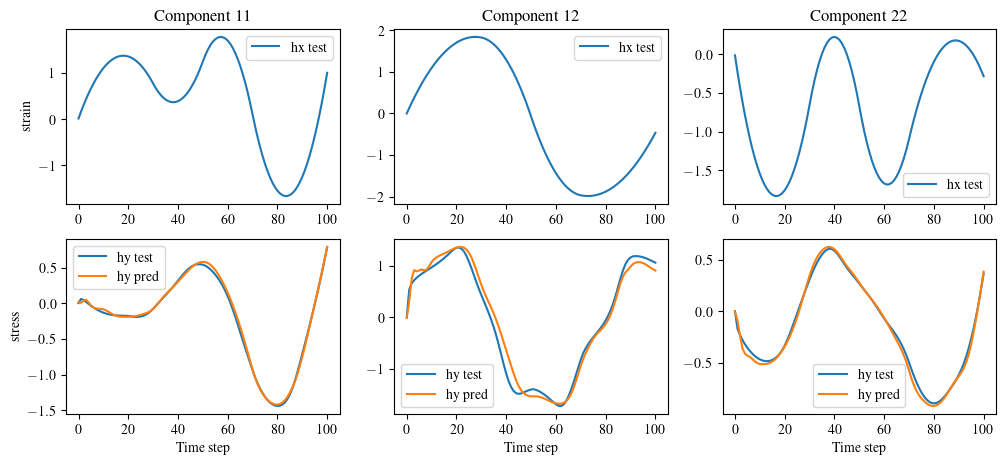

In [5]:
index = 2
hy_pred = mf_model.hf_predict(dataset.hx_id_gt_scaled)
fig, ax = plt.subplots(2, 3, figsize=(12, 5))
for i in range(3):
    ax[0, i].plot(dataset.hx_id_gt_scaled[index, :, i], label='hx test')
    ax[0, i].legend()
    ax[1, i].plot(dataset.hy_id_gt_scaled[index, :, i], label='hy test')
    ax[1, i].plot(hy_pred[index, :, i].cpu(), label='hy pred')
    ax[1, i].legend()
for i in range(3):
    ax[1, i].set_xlabel('Time step')

ax[0, 0].set_ylabel('strain')
ax[1, 0].set_ylabel('stress')
# set the title
ax[0, 0].set_title('Component 11')
ax[0, 1].set_title('Component 12')
ax[0, 2].set_title('Component 22')
plt.show()


## Have fun! 